In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from AnalyzeDataset import AnalyzeDataset


## Table Of Contents:  
> Load the data  
> Initialize the Class: AD = AnalyzeDataset()    
> Call Fit: AD.fit_full_dataset_analysis(df) 
> Produce a DataFrame to View Fit Results: AD.column_relationships_df() 
> Plotting Options  
  

### Load data  

In [15]:
import Consumer_Habits_file_loader
from Consumer_Habits_file_loader import load_consumer_habits
df = load_consumer_habits('shopping_behavior_updated.csv')

\\wsl.localhost\Ubuntu\home\lelandmesford\Projects\Consumer_Habits\utils\Consumer_Habits_file_loader.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Male']=df['Gender'].replace({'Male':1,'Female':0}).astype('object')


# Initialize the Class with Default Parameters

In [16]:
# params: 
kruskal_assumption_check_params = {'levene_alpha':0.01,'ks_alpha':0.01,'return_pseudo':True, 'pseudo_test_max_global_ties_ratio': 0.7,
                                    'full_pseudo':False,'dropna':True, 'n_jobs':-8, 'guesstimate':{'rej_max_pct_in_group':0.2,
                                    'max_num_outlier_all_reject':3, 'max_pct_reject_total':0.2}}
anova_assumption_check_params   = {'normality_alpha':0.01, 'homogeneity_alpha':0.01, 'min_n':5, 'iqr_multiplier':2, 'dropna':True} 
chi2_assumption_check_params    = {'dropna':True}
supercat_subcat_params          = {'max_evidence':0.2,  'isolate_super_subs':False }
multivariate_params             = {'max_n_combination_size':3, 'max_n_combinations':50_000,  'min_combo_size':2}
multivariate_concatenation_delimiter = "_|&|_" 
numnum_meth_alpha_above_instructions = [('pearson',0.6,None),('spearman',0.6,None),('kendall',0.6,None)]
numcat_meth_alpha_above_instructions = [('kruskal',0.05,None),('anova',0.05,None)]
catcat_meth_alpha_above_instructions = [('chi2',0.05,None)] 
good_of_fit_uniform_test_instrucions = (0.05,None) 
normal_test_instructions             = (0.05,None) 


AD = AnalyzeDataset(multivariate_params = multivariate_params,
                        kruskal_assumption_check_params=kruskal_assumption_check_params,
                        anova_assumption_check_params = anova_assumption_check_params,
                        chi2_assumption_check_params = chi2_assumption_check_params,
                        supercat_subcat_params = supercat_subcat_params,
                        multivariate_concatenation_delimiter = multivariate_concatenation_delimiter,
                        numnum_meth_alpha_above_instructions=numnum_meth_alpha_above_instructions,
                        numcat_meth_alpha_above_instructions=numcat_meth_alpha_above_instructions,
                        catcat_meth_alpha_above_instructions=catcat_meth_alpha_above_instructions,
                        good_of_fit_uniform_test_instrucions=good_of_fit_uniform_test_instrucions,
                        normal_test_instructions=normal_test_instructions
                        )

              
                          
                          

# Fit statistically significant differences  
where fit_mulitvariates==True can have a big impact on compute time.  

In [27]:
AD.fit_full_dataset_analysis(df,  
                            numeric_columns=None,         # None for autodetect
                            categoric_columns=None,       # None for autodetect
                            numeric_target=None,          # None to compute all numeric varaibles as targets
                            categoric_target=None,        # None to compute all categoric varaibles as targets                          
                            fit_good_of_fit=True,         # instruct to test categoric variables for uniform distribution
                            fit_normal=True,
                            fit_multivariates=True,       # instruct to test multivariate significance
                            fit_supercat_subcats=True)    # test for supercategories with subcategories that partition other variables

# A dataframe to summarize fit results based on rejected nulls and correlations above thresholds

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth',None)
display(AD.column_relationships_df(targets=None))

Where 'MaxLenComboComparedTo' can vary depending on compute limits and number of possible combinations in combo sizes.
'FeatureColum(s)' is a combination or single column that shares a significant relationship according to the test(s).
'Test(s)' lists the test(s) used. If the testname is followed by a colon, that signals whether assumptions were met for that specifit test.


FeatureColum(s)  \
Target                  Type      Distrubition           MaxLenCombosComparedTo                                                            
Size                    categoric reject_uniform         3                                                                 Review Rating   
Male                    categoric reject_uniform         3                                                            Previous Purchases   
                                                         3                                                              Discount Applied   
                                                         3                                                           Subscription Status   
                                                         3                                                                 Shipping Type   
                                                         3                                                               Promo Code Used   
                                                         3                                               [Color, Frequency of Purchases]   
Subscription Status     categoric reject_uniform         3                                                              Discount Applied   
                                                         3                                                                          Male   
                                                         3                                                               Promo Code Used   
                                                         3                                                        [Item Purchased, Size]   
                                                         3                                                       [Season, Shipping Type]   
Previous Purchases      numeric   reject_normal          3                                                                          Male   
                                                         3                                                                Item Purchased   
                                                         3                                                [Frequency of Purchases, Size]   
                                                         3                                            [Frequency of Purchases, Location]   
                                                         3                                               [Category, Subscription Status]   
Age                     numeric   reject_normal          3                                               [Location, Male, Shipping Type]   
                                                         3                       [Frequency of Purchases, Location, Subscription Status]   
                                                         3                                  [Category, Frequency of Purchases, Location]   
                                                         3                              [Frequency of Purchases, Item Purchased, Season]   
                                                         3                       [Frequency of Purchases, Payment Method, Shipping Type]   
                                                         3                             [Category, Frequency of Purchases, Shipping Type]   
Promo Code Used         categoric reject_uniform         3                                                              Discount Applied   
                                                         3                                                                          Male   
                                                         3                                                           Subscription Status   
                                                         3                                [Frequency of Purchases, Payment Method, Size]   
Frequency of Purchases  categoric fail_to_reject_uniform 3   

# Low Level Details

### Access Results Globally for the Entire Dataset  

In [29]:
print('Categorical Columns that Rejected the Goodness-of-Fit Test for a Uniform Distribution'.upper())
print('          ',AD.reject_null_good_of_fit)
print('Categorical that Failed to Reject Uniform Distribution'.upper())
print('          ',AD.fail_to_reject_null_good_of_fit)
print('Numerical Columns that Rejected a test for Normal Distribution'.upper())
print('          ',AD.reject_null_normal)
print('Numerical that Failed to Reject a test for a Normal Distribution'.upper())
print('          ',AD.fail_to_reject_null_normal)
print('Numeric-Numeric Bivariates with Correlaiton Above the Threshold'.upper())
print('          ',AD.above_threshold_corr_numnum) 
print('Numeric-Numeric Bivariates with Correlaiton Below the Threshold'.upper())
print('          ',AD.below_threshold_corr_numnum)
print('Numeric-Categoric Bivariates that Rejected the Null Hypothesis'.upper())
print('          ',AD.reject_null_numcat)
print('Numeric-Categoric Bivariates that Failed to Reject the Null Hypothesis'.upper())
print('          ',AD.fail_to_reject_null_numcat)
print('Categoric-Categoric Bivariates that Rejected the Null Hypothesis'.upper())
print('          ',AD.reject_null_catcat)
print('Categoric-Categoric Bivariates that Failed to Reject the Null Hypothesis'.upper())
print('          ',AD.fail_to_reject_null_catcat)
print('Supercategory variables that partition another variable into Subcategories'.upper())
print('          ',AD.supercategory_subcategory_pairs)
print('Multivariat variables. Target and target type followed by a combination of categoric variables. Then the test type.'.upper())
print('          ',AD.significant_multivariate_combinations)
print('Univariate and Bivariate cases where test assumptions were not met.'.upper())
for k,v in AD.assumptions_not_met.items():
    print('          ',k,':  ',v)

CATEGORICAL COLUMNS THAT REJECTED THE GOODNESS-OF-FIT TEST FOR A UNIFORM DISTRIBUTION
           {'Discount Applied', 'Size', 'Male', 'Subscription Status', 'Promo Code Used', 'Category'}
CATEGORICAL THAT FAILED TO REJECT UNIFORM DISTRIBUTION
           {'Location', 'Season', 'Color', 'Payment Method', 'Shipping Type', 'Frequency of Purchases', 'Item Purchased'}
NUMERICAL COLUMNS THAT REJECTED A TEST FOR NORMAL DISTRIBUTION
           {'Total Days of Patronage', 'Previous Purchases', 'Age', 'Review Rating', 'Purchase Amount (USD)'}
NUMERICAL THAT FAILED TO REJECT A TEST FOR A NORMAL DISTRIBUTION
           set()
NUMERIC-NUMERIC BIVARIATES WITH CORRELAITON ABOVE THE THRESHOLD
           []
NUMERIC-NUMERIC BIVARIATES WITH CORRELAITON BELOW THE THRESHOLD
           [['Age', 'Purchase Amount (USD)'], ['Age', 'Review Rating'], ['Age', 'Previous Purchases'], ['Age', 'Total Days of Patronage'], ['Purchase Amount (USD)', 'Review Rating'], ['Previous Purchases', 'Purchase Amount (USD)'], ['Purc

## ====================================================================================================   
# High Level Visuals   
## ====================================================================================================  

## Two Plot Functions W/ Dynamic Output

In [30]:
# parameters:
cat_univar_params =         {'proportions':False,'n_wide':(6,40,4),
                             'super_title':"Univariate Categorical Variables - Reject Good-Of-Fit for Uniform"}
catcat_bivar_params =       {'n_wide':(6,40,5),'stacked_bars_when_max_bars_is_exceeded':True,'sorted':False,
                             'super_title':"Categoric-To-Categoric Bivariates - Reject Null"}
numnum_bivar_params =       {'plot_type':'joint','linreg':True,'plot_type_kwargs':None,'linreg_kwargs':None,
                             'super_title':'Numeric Bivariates With Significant Correlation(s)'}
numcat_bivar_params =       {'plot_type':'boxen', 'n_wide':(6,40,8), 
                             'super_title':'Numeric-to-Categoric Bivariates  - Reject Null' }
super_subcat_pairs_params = {'row_height':2,'cols_per_row':3,'y_tick_fontsize':12,
                             'super_title':"Supercategory-Subcategory - One Categoric Variable Partitions Another"} 
num_univar_params =         {'kde':None,'proportions':False,'n_wide':(6,40,4),
                             'super_title':"Univariate Numerical Variables - Reject Normal Distribution",
                             'force_significant_bin_edges':None,  'minimize_significant_bins':None, 'include_multivariate':True} 



### Plot by input pairs, infer rejected null and correlation above threshold, or set to False   

In [31]:
# plots based on what has been fit globally
AD.produce_all_plots(df,
                    cat_univar=False,   # None or True indicate variables should be derived from fit results. Otherwise input list or str
                    num_univar=False, 
                    catcat_bivar=False,
                    numnum_bivar=False,
                    numcat_bivar=AD.assumptions_not_met['numcat'],    # can manually input valus. such as: AD.assumptions_not_met['numcat']
                    super_subcat_pairs=False,
                    cat_univar_params = cat_univar_params,
                    catcat_bivar_params = catcat_bivar_params,
                    numnum_bivar_params = numnum_bivar_params,
                    numcat_bivar_params = {'super_title':"Assumptions Not Met"}, # numcat_bivar_params,
                    super_subcat_pairs_params = super_subcat_pairs_params,
                    num_univar_params = num_univar_params
                  )

Plot Categoric Univariate is set to False
Plot Numeric Univariate is set to False
Plot Bivariate Categoric-Categoric is set to False
Plot Bivariate Numeric-Numeric is set to False
There are not any numeric-to-categoric column pairs with significant relationships.
Either none exist, or they haven't been fit.
Plot Supercategory-Subcategory Partitions is set to False


### Plot individual targets based on reject null and correlation above threshold  
### Set how targets are output with the targets_share_plots perameter

= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 
SIGNIFICANT VISUALIZATIONS FOR Review Rating
Non-Value Plots will Automatically be set to False
Plot Categoric Univariate is set to False


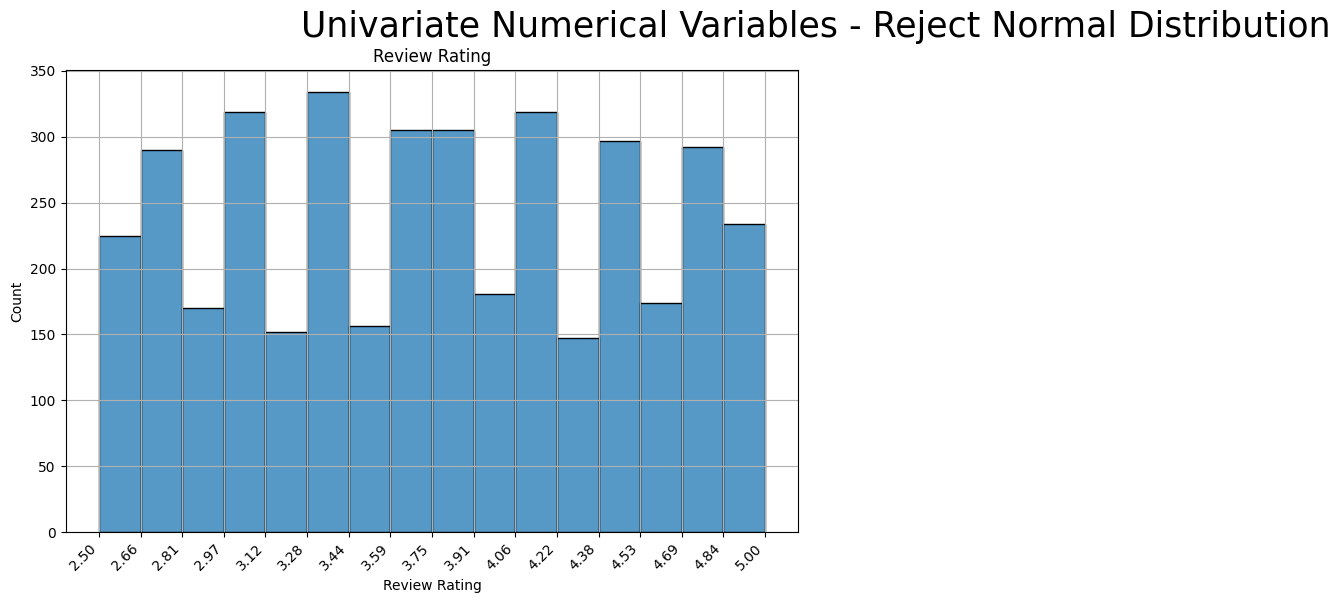

Plot Bivariate Categoric-Categoric is set to False
Plot Bivariate Numeric-Numeric is set to False


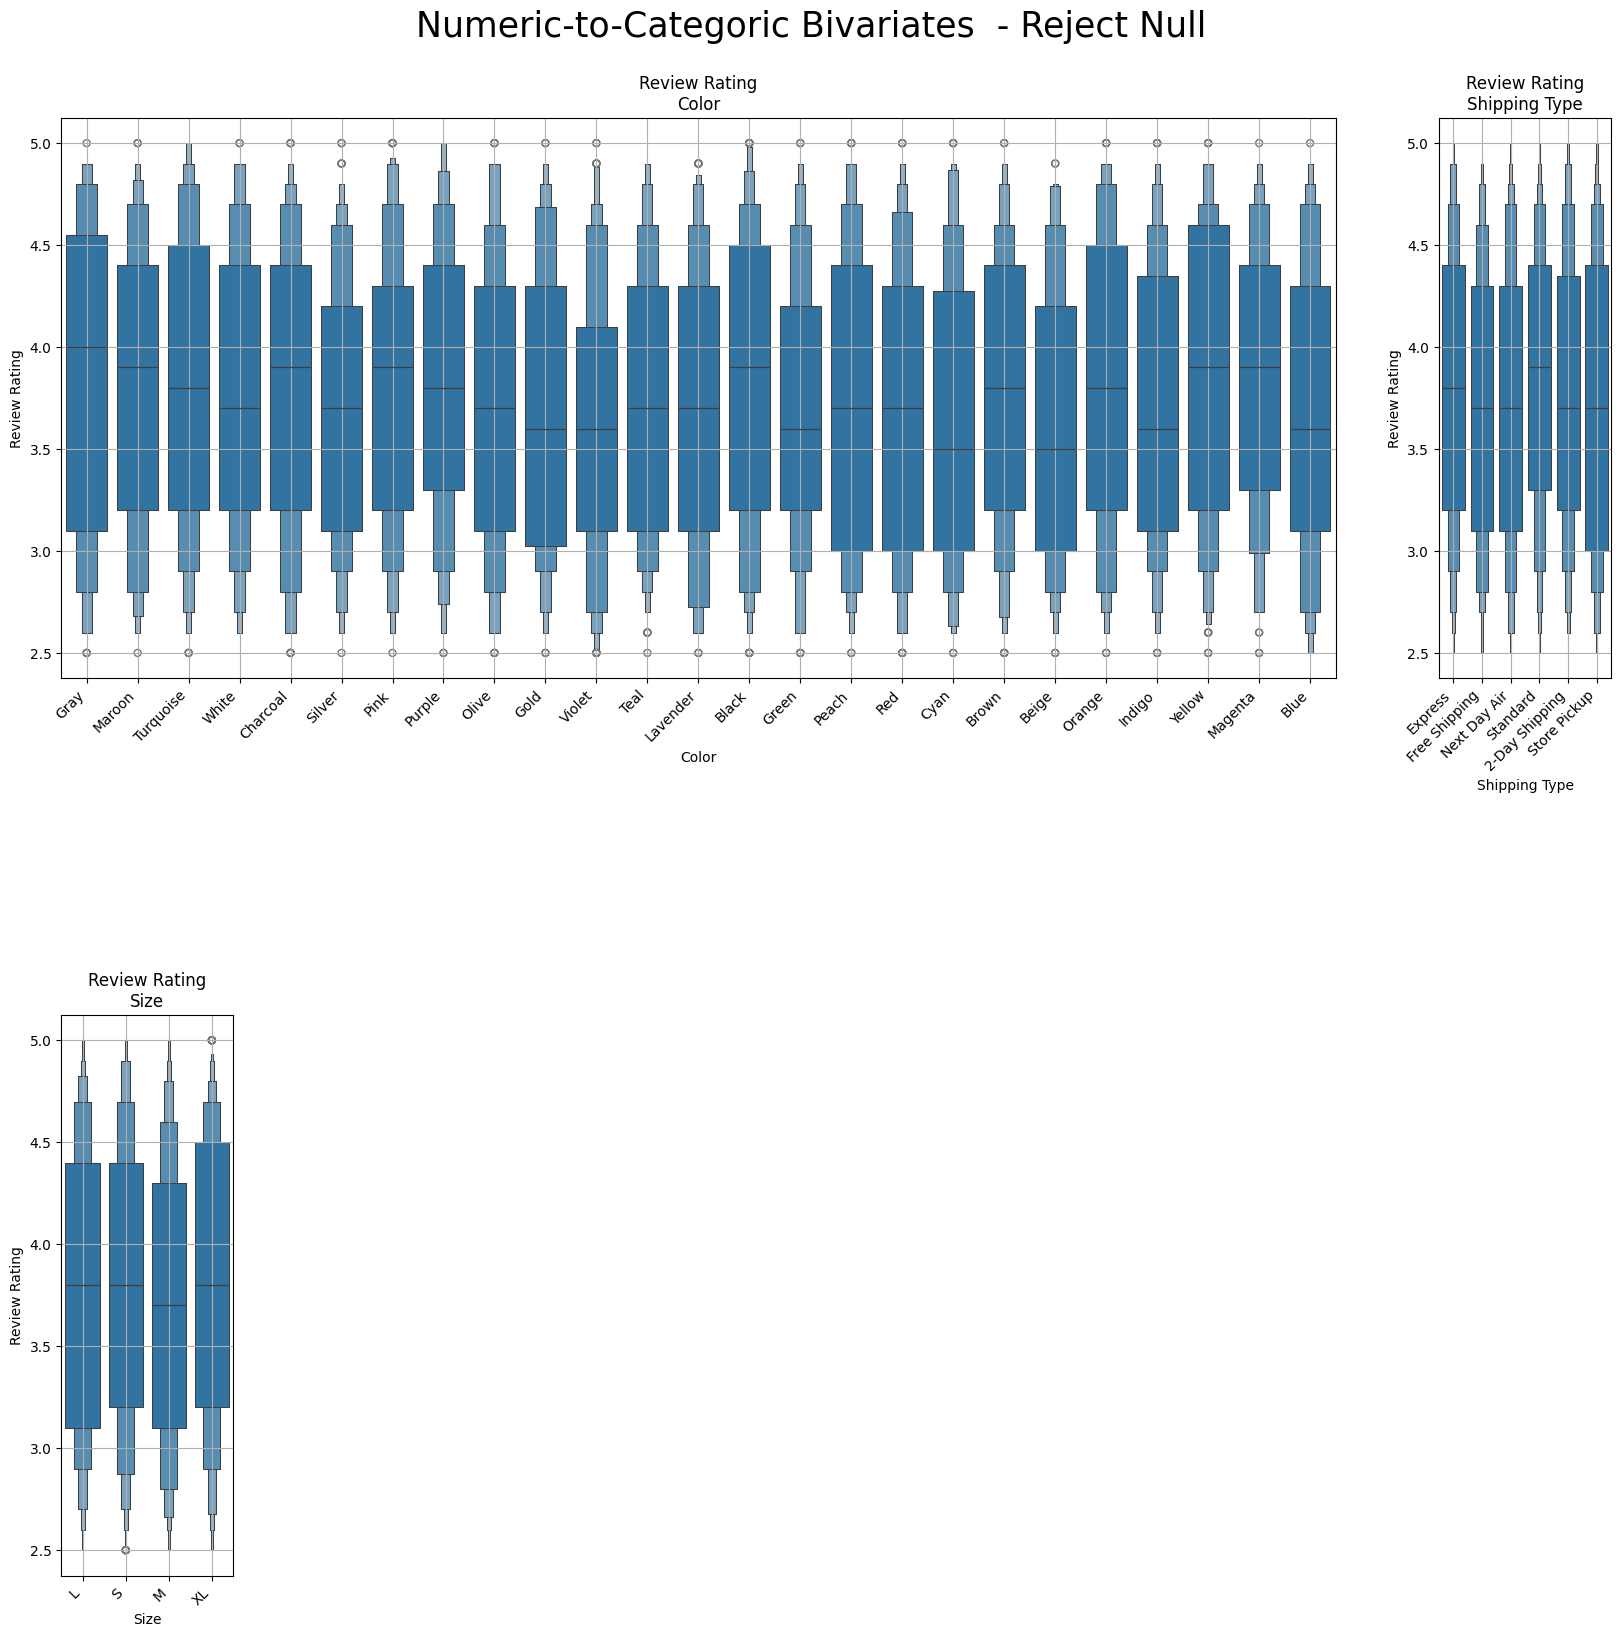

Plot Supercategory-Subcategory Partitions is set to False
= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 


In [32]:
# this one calls the other internally, but plots data based on per
AD.visualize_by_targets(
                        data=df,
                        targets='Review Rating',      # targets are input here
                        reject_numcat=True,  # WHETHER TO PLOT OR NOT
                        reject_numnum=True,
                        reject_catcat=True,
                        is_super_or_subcat=True,
                        not_uniform_or_reject_normal=True,  
                        reject_multivariates=False,        # multivariate plots are not yet supported
                        auto_fit=True,   # to call fit function(s) when needed
                        targets_share_plots=False ,  # otherwise targets are plotted individually
                        check_assumptions=True,
                        dropna_gof=True,
                        cat_univar_params = cat_univar_params,
                        catcat_bivar_params = catcat_bivar_params,
                        numnum_bivar_params = numnum_bivar_params,
                        numcat_bivar_params = numcat_bivar_params,
                        super_subcat_pairs_params = super_subcat_pairs_params,
                        num_univar_params = num_univar_params
                        )

## Histogram bin edges can be controlled such as to minimize number of bins while keeping statistical significant thresholds
## Or to exclude multivariate combinations

Pre examination of binning metrics for Total Days of Patronage show a per variable bin range of [2,556]:   
Plots vary based on using minimums, multivar, or max of min -vs- default

In [33]:
mn,mp = AD.get_a_varaibles_binning_metrics(df,
                                        target='Total Days of Patronage',
                                        check_multivar=True)
print('='*23)
print('Total Days of Patronage')
print('Absolute min bins: ', mn)
print('Bin meta: ',mp)
print('='*23)


Total Days of Patronage
Absolute min bins:  556
Bin meta:  {'Location_|&|_Male_|&|_Size': 197, 'Promo Code Used_|&|_Season_|&|_Size': 34, 'Frequency of Purchases': 2, 'Discount Applied_|&|_Season_|&|_Size': 34, 'Location_|&|_Male_|&|_Season': 556, 'Male_|&|_Season_|&|_Size': 56}


In [34]:
pd.DataFrame({k:[v] for k,v in mp.items()})

,Location_|&|_Male_|&|_Size,Promo Code Used_|&|_Season_|&|_Size,Frequency of Purchases,Discount Applied_|&|_Season_|&|_Size,Location_|&|_Male_|&|_Season,Male_|&|_Season_|&|_Size
0,197,34,2,34,556,56


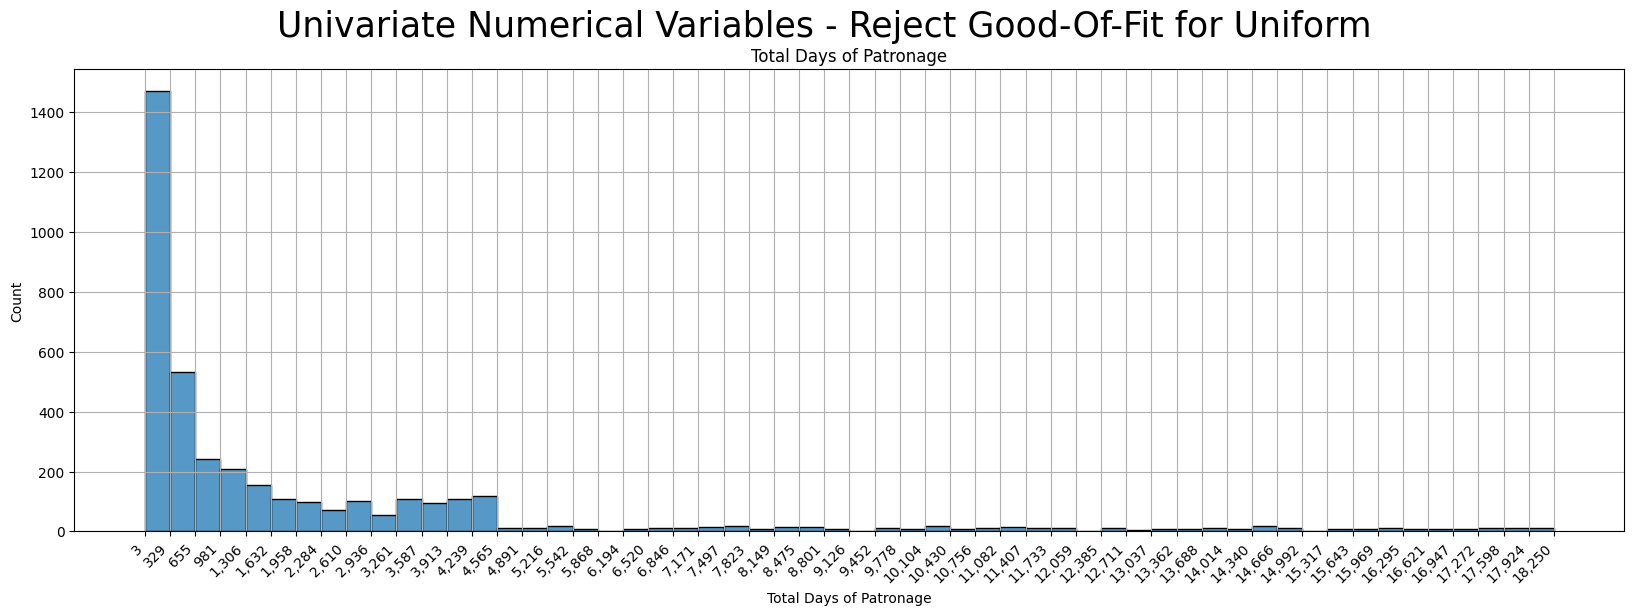

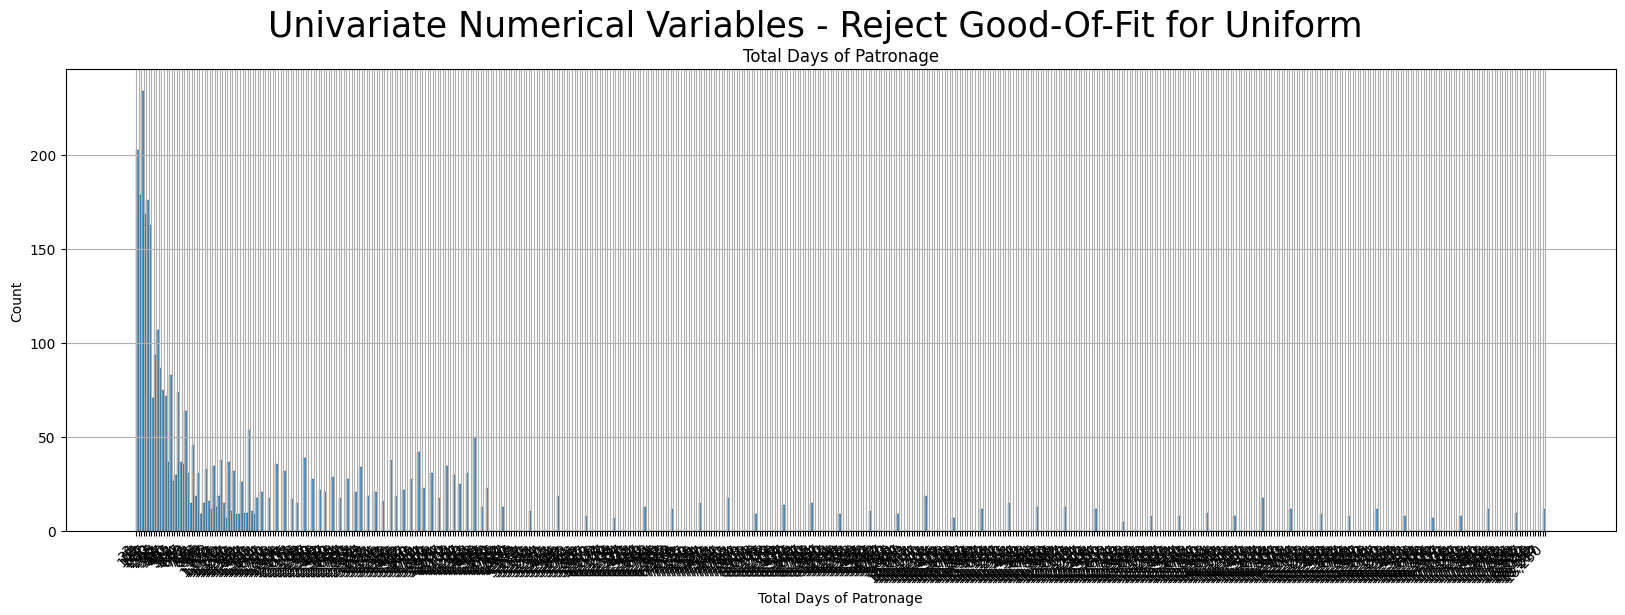

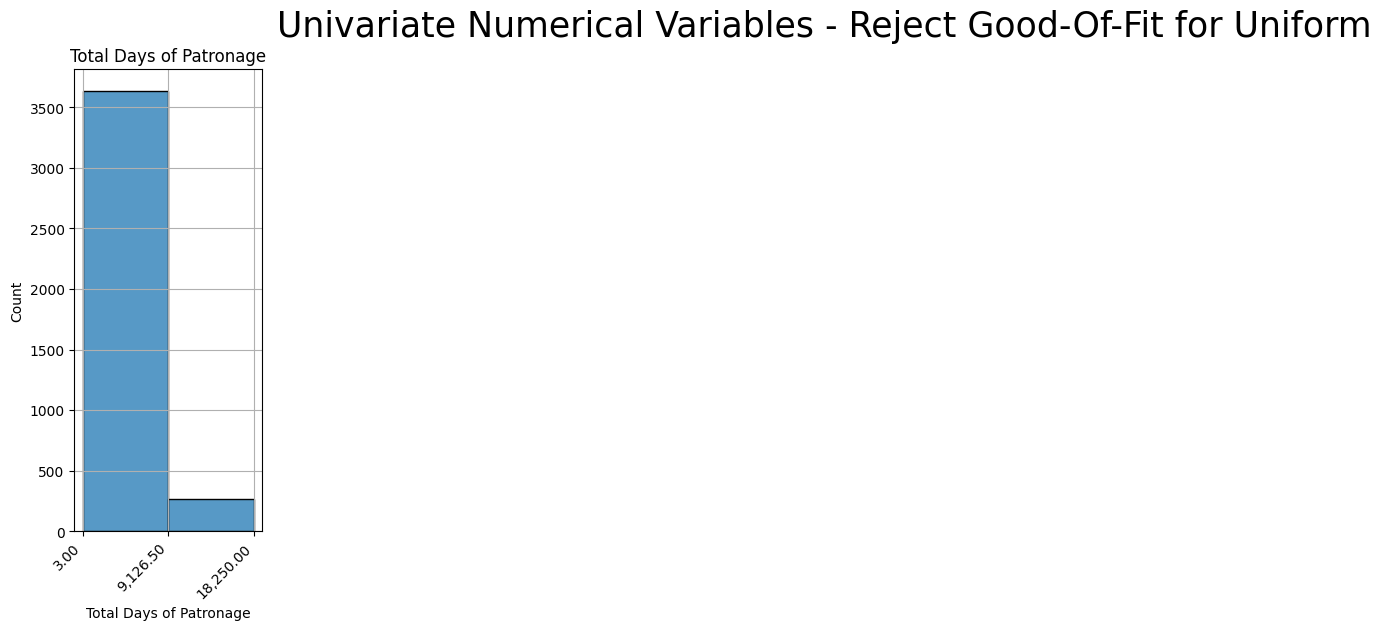

In [35]:
AD.plot_non_normal_numeric(df,
                           numerical= ['Total Days of Patronage'])
AD.plot_non_normal_numeric(df,
                           numerical= ['Total Days of Patronage'],
                            force_significant_bin_edges=True,
                            minimize_significant_bins=True,
                            include_multivariate=True)
AD.plot_non_normal_numeric(df,
                           numerical= ['Total Days of Patronage'],
                            force_significant_bin_edges=True,
                            minimize_significant_bins=True,
                            include_multivariate=False)

# Produce all significant plots in one shot

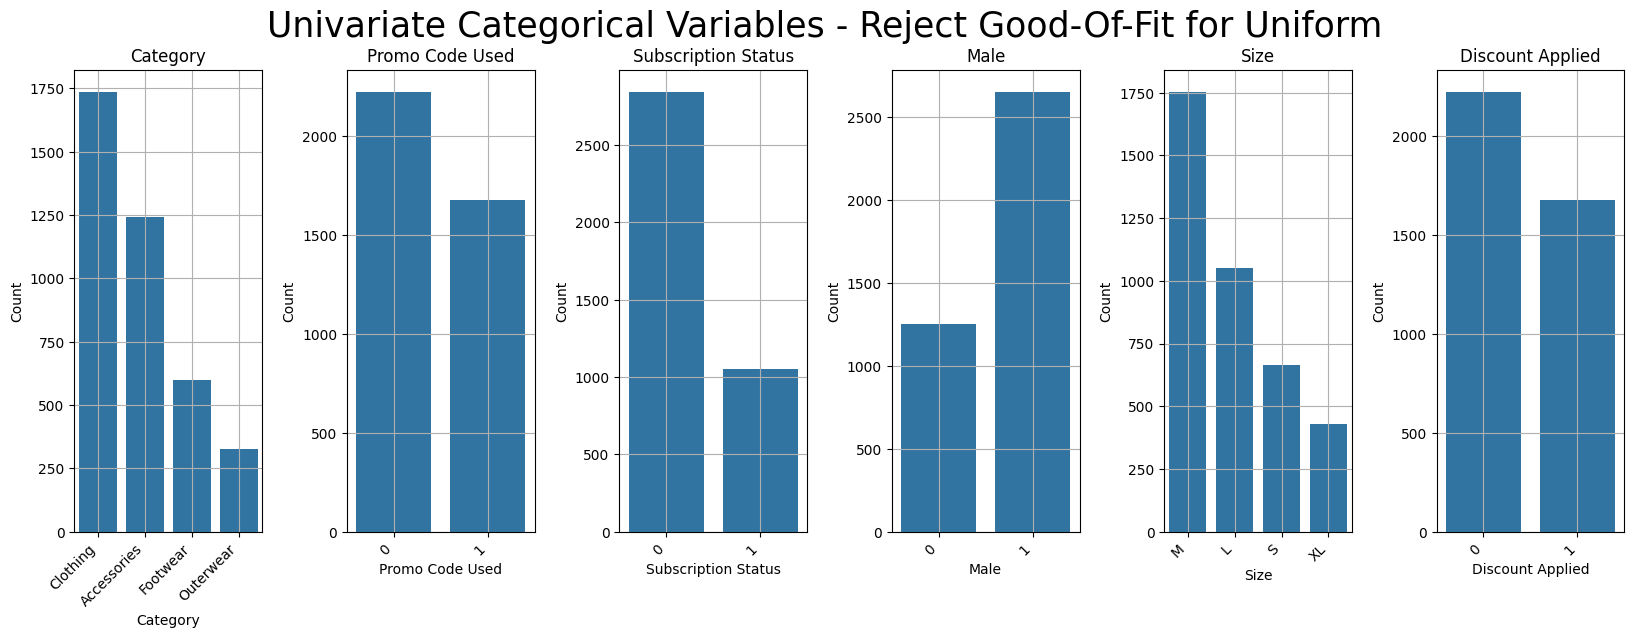

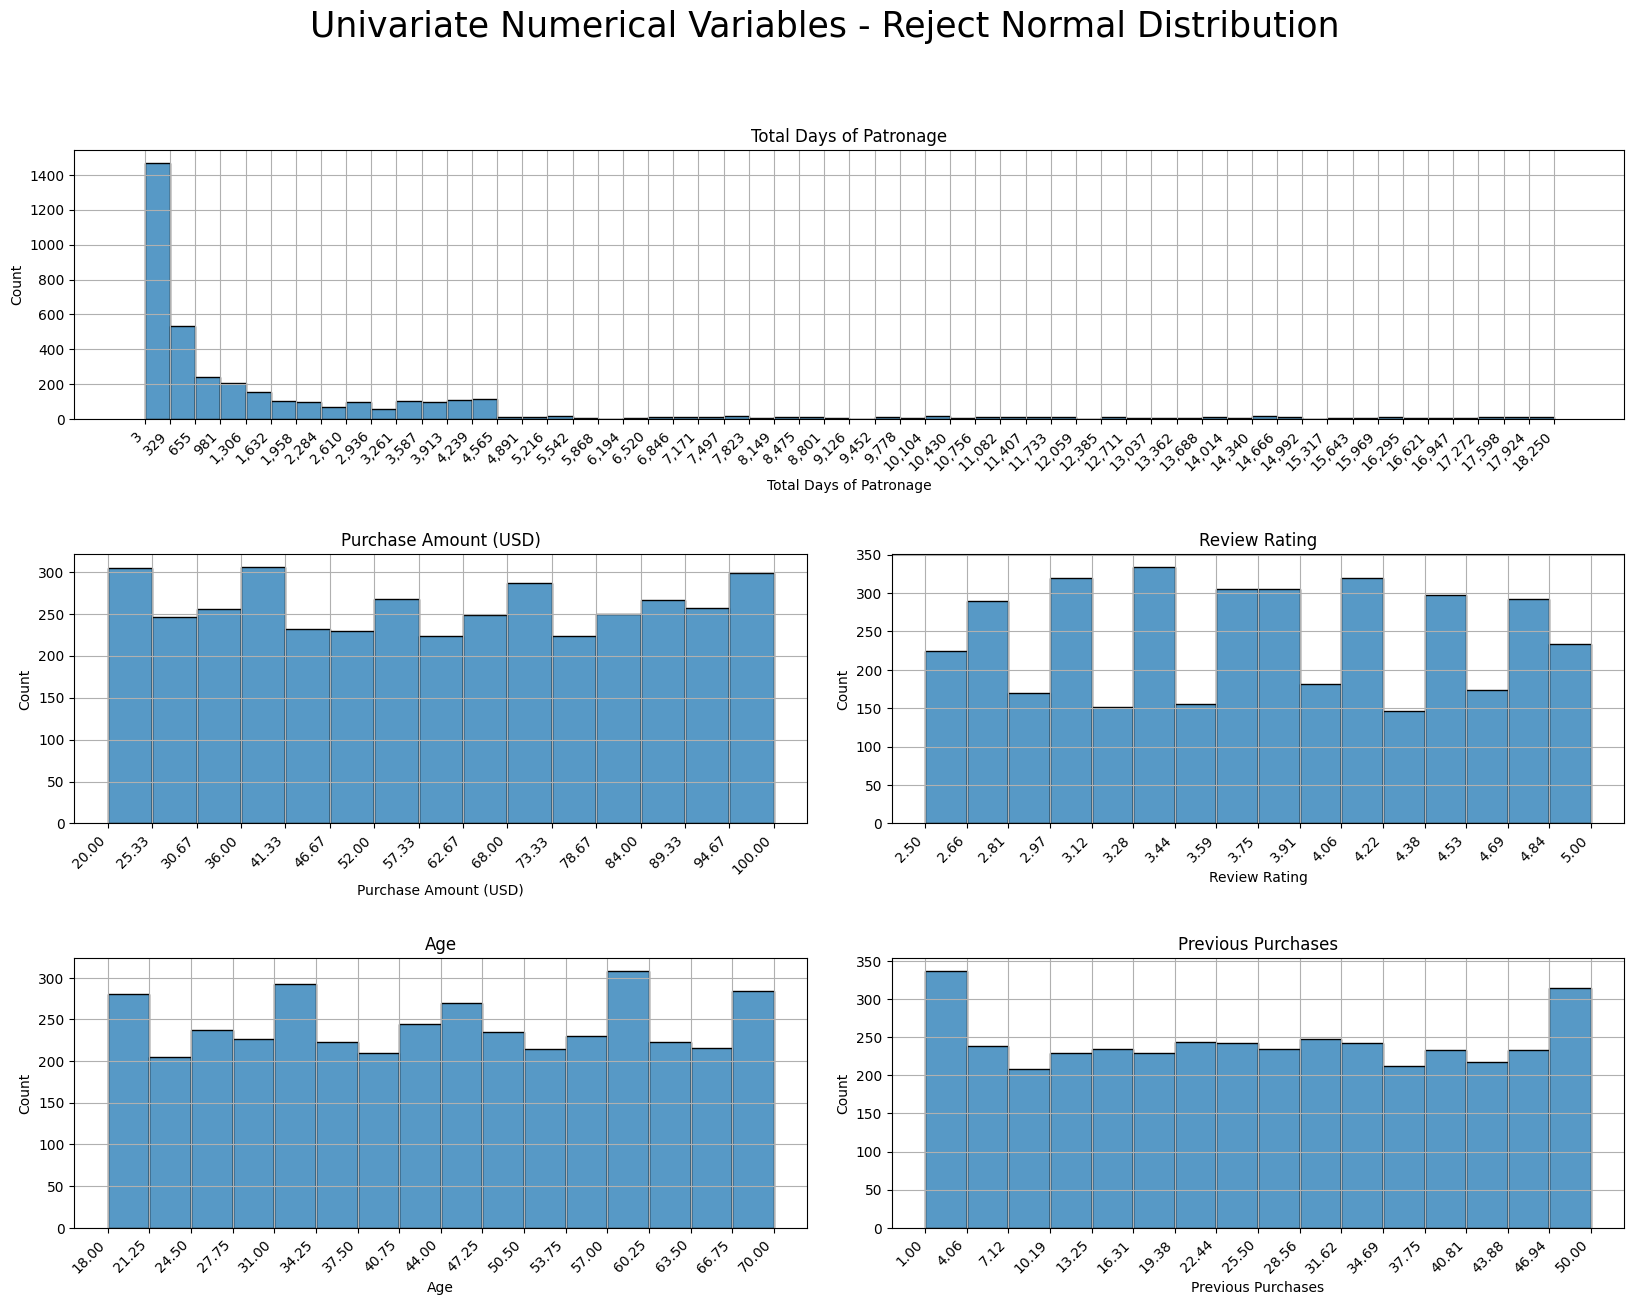

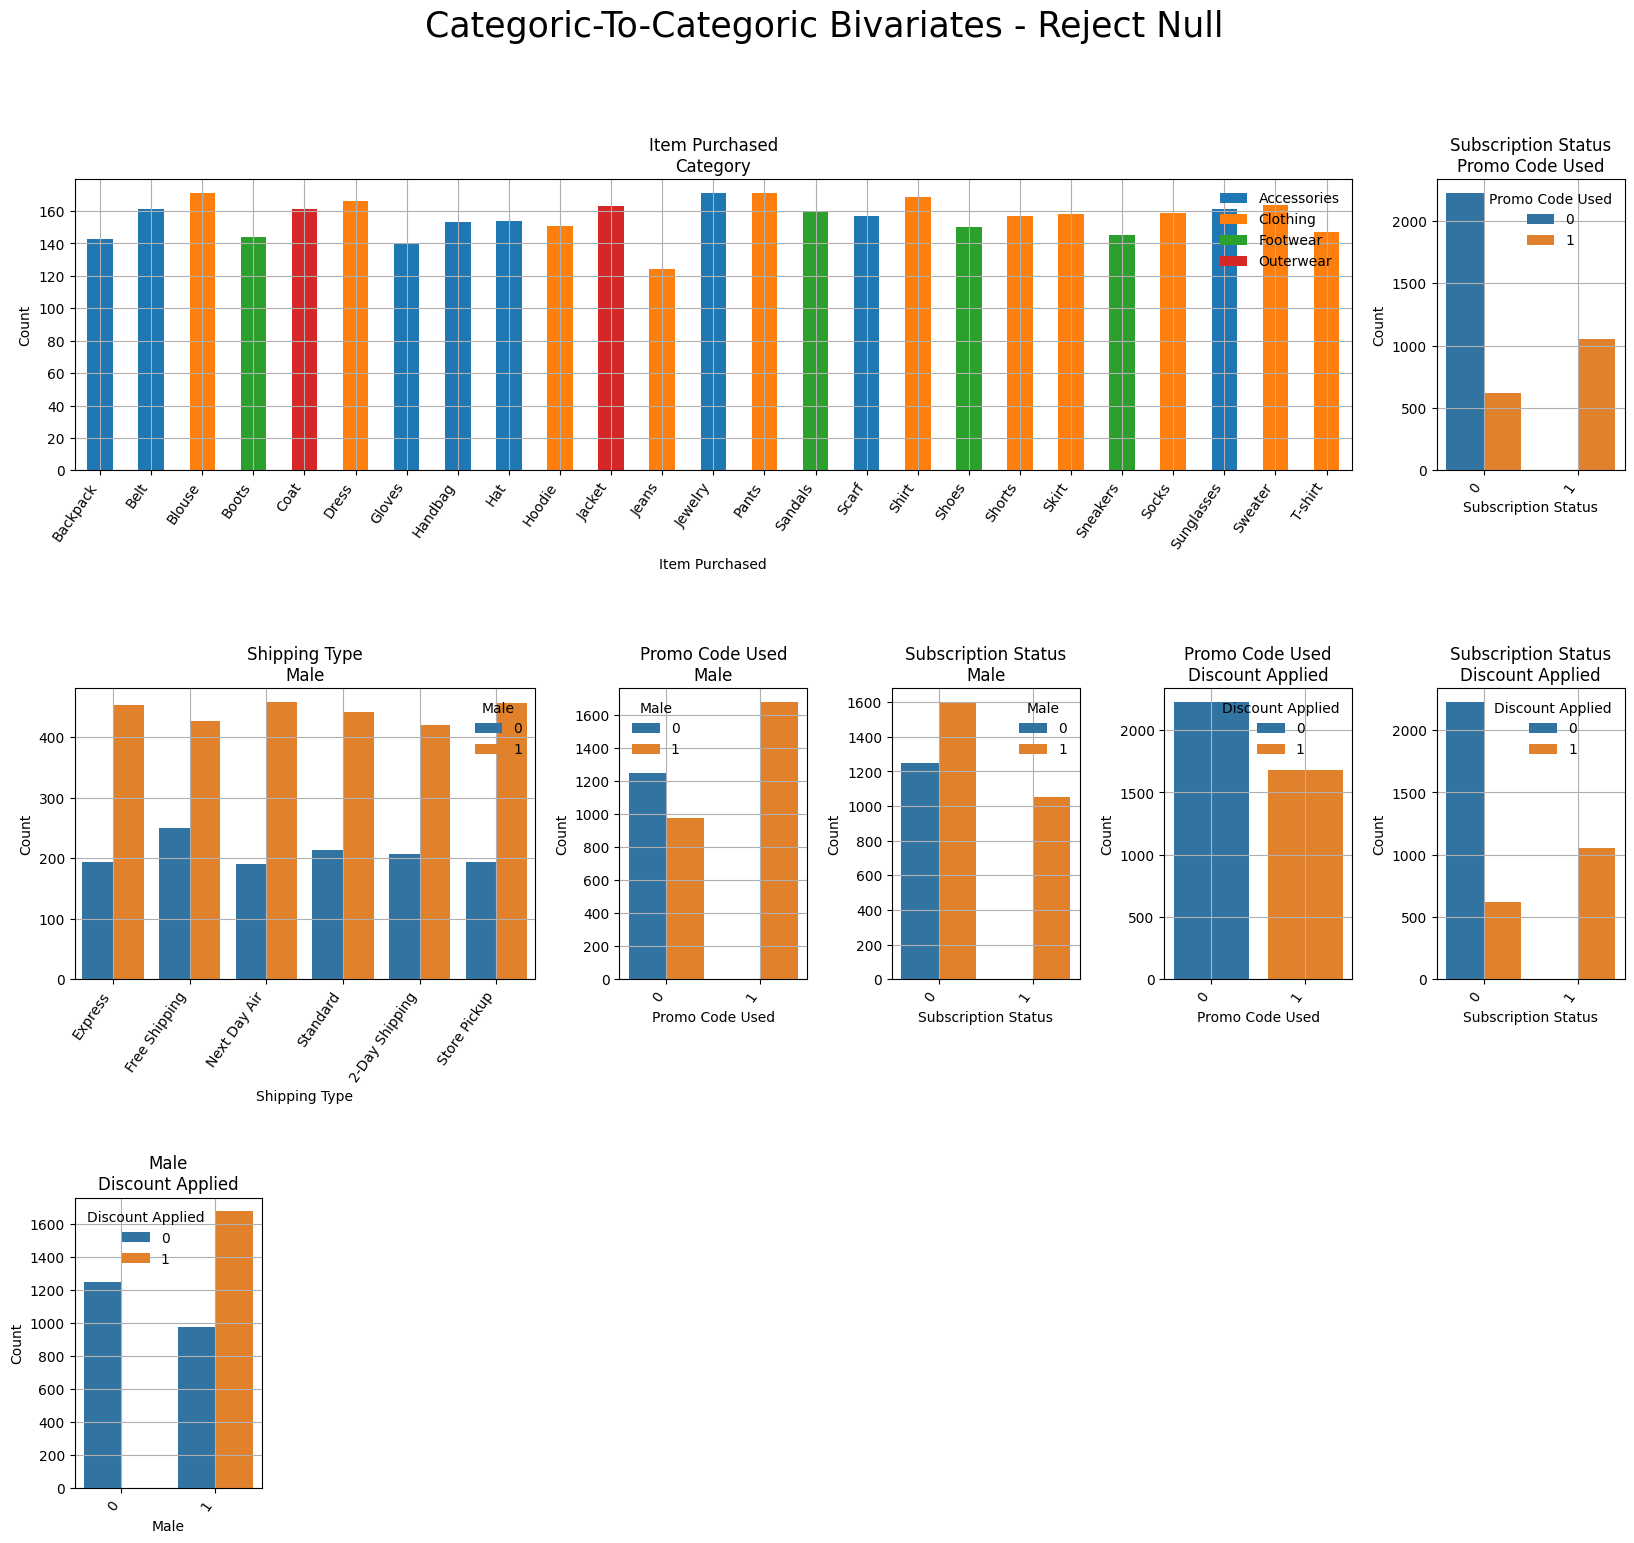

The model does not contain any numeric-to-numeric column pairs with significant relationships.
Either none exist, or they haven't been fit.


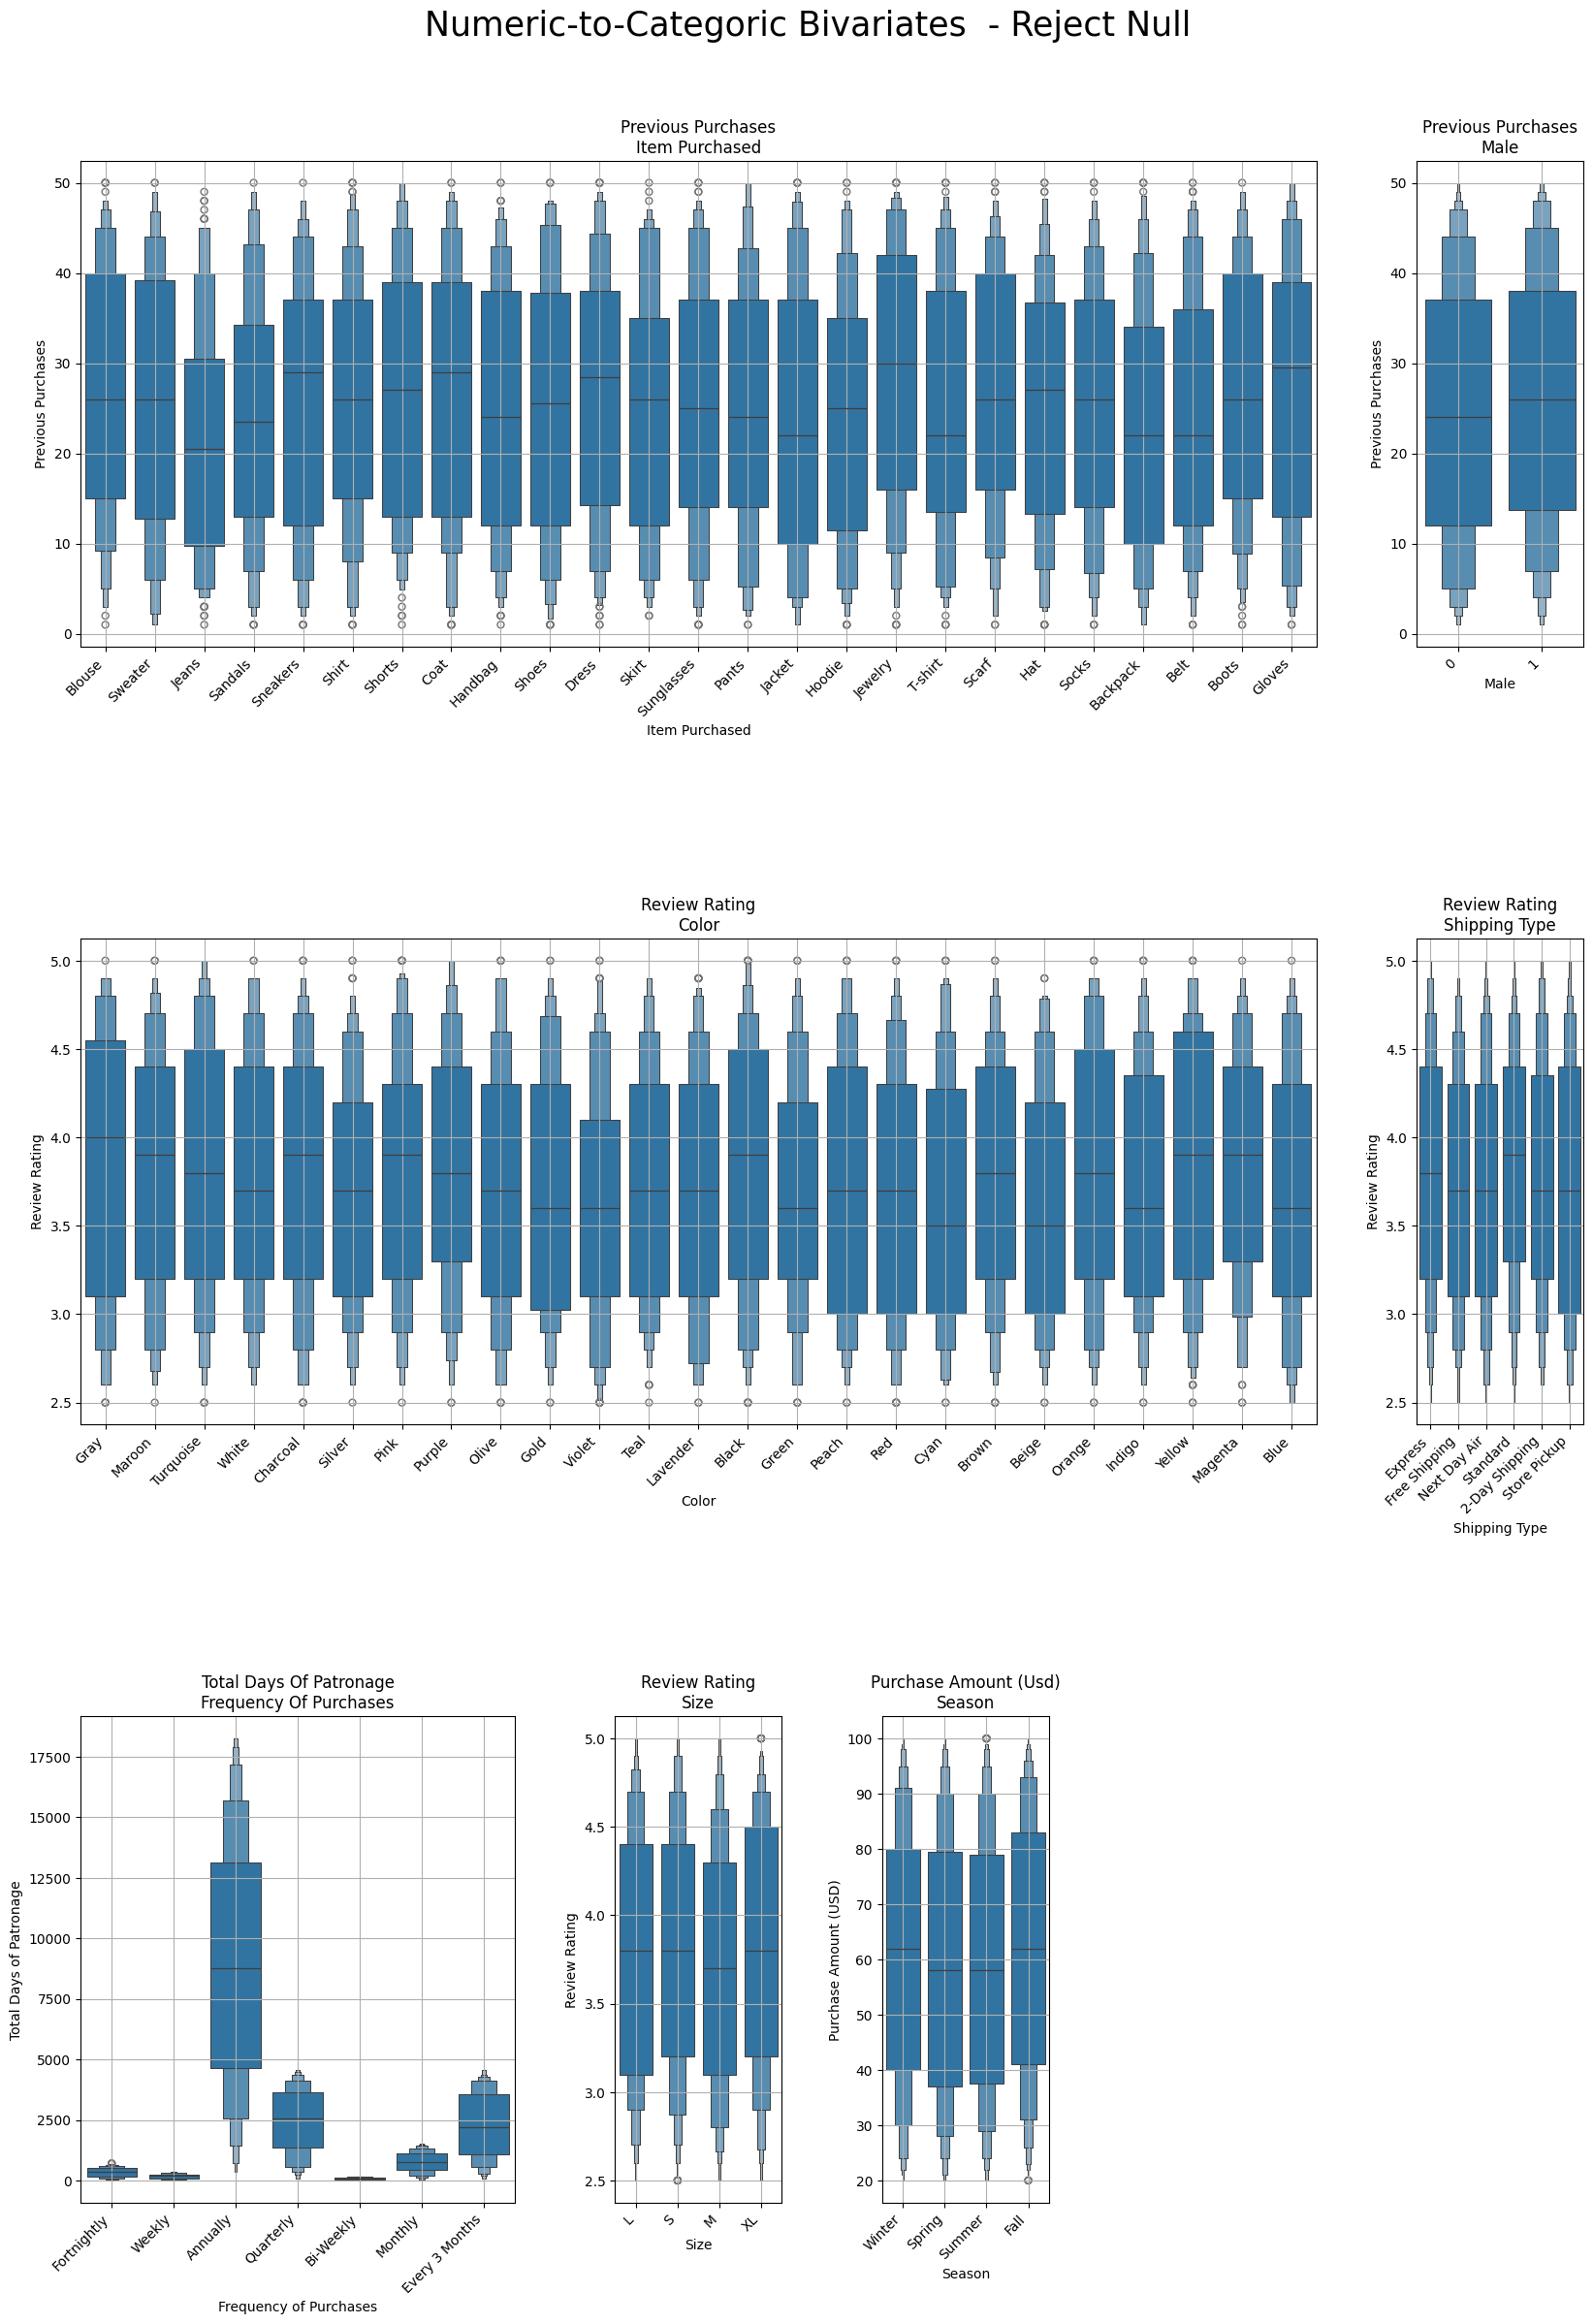

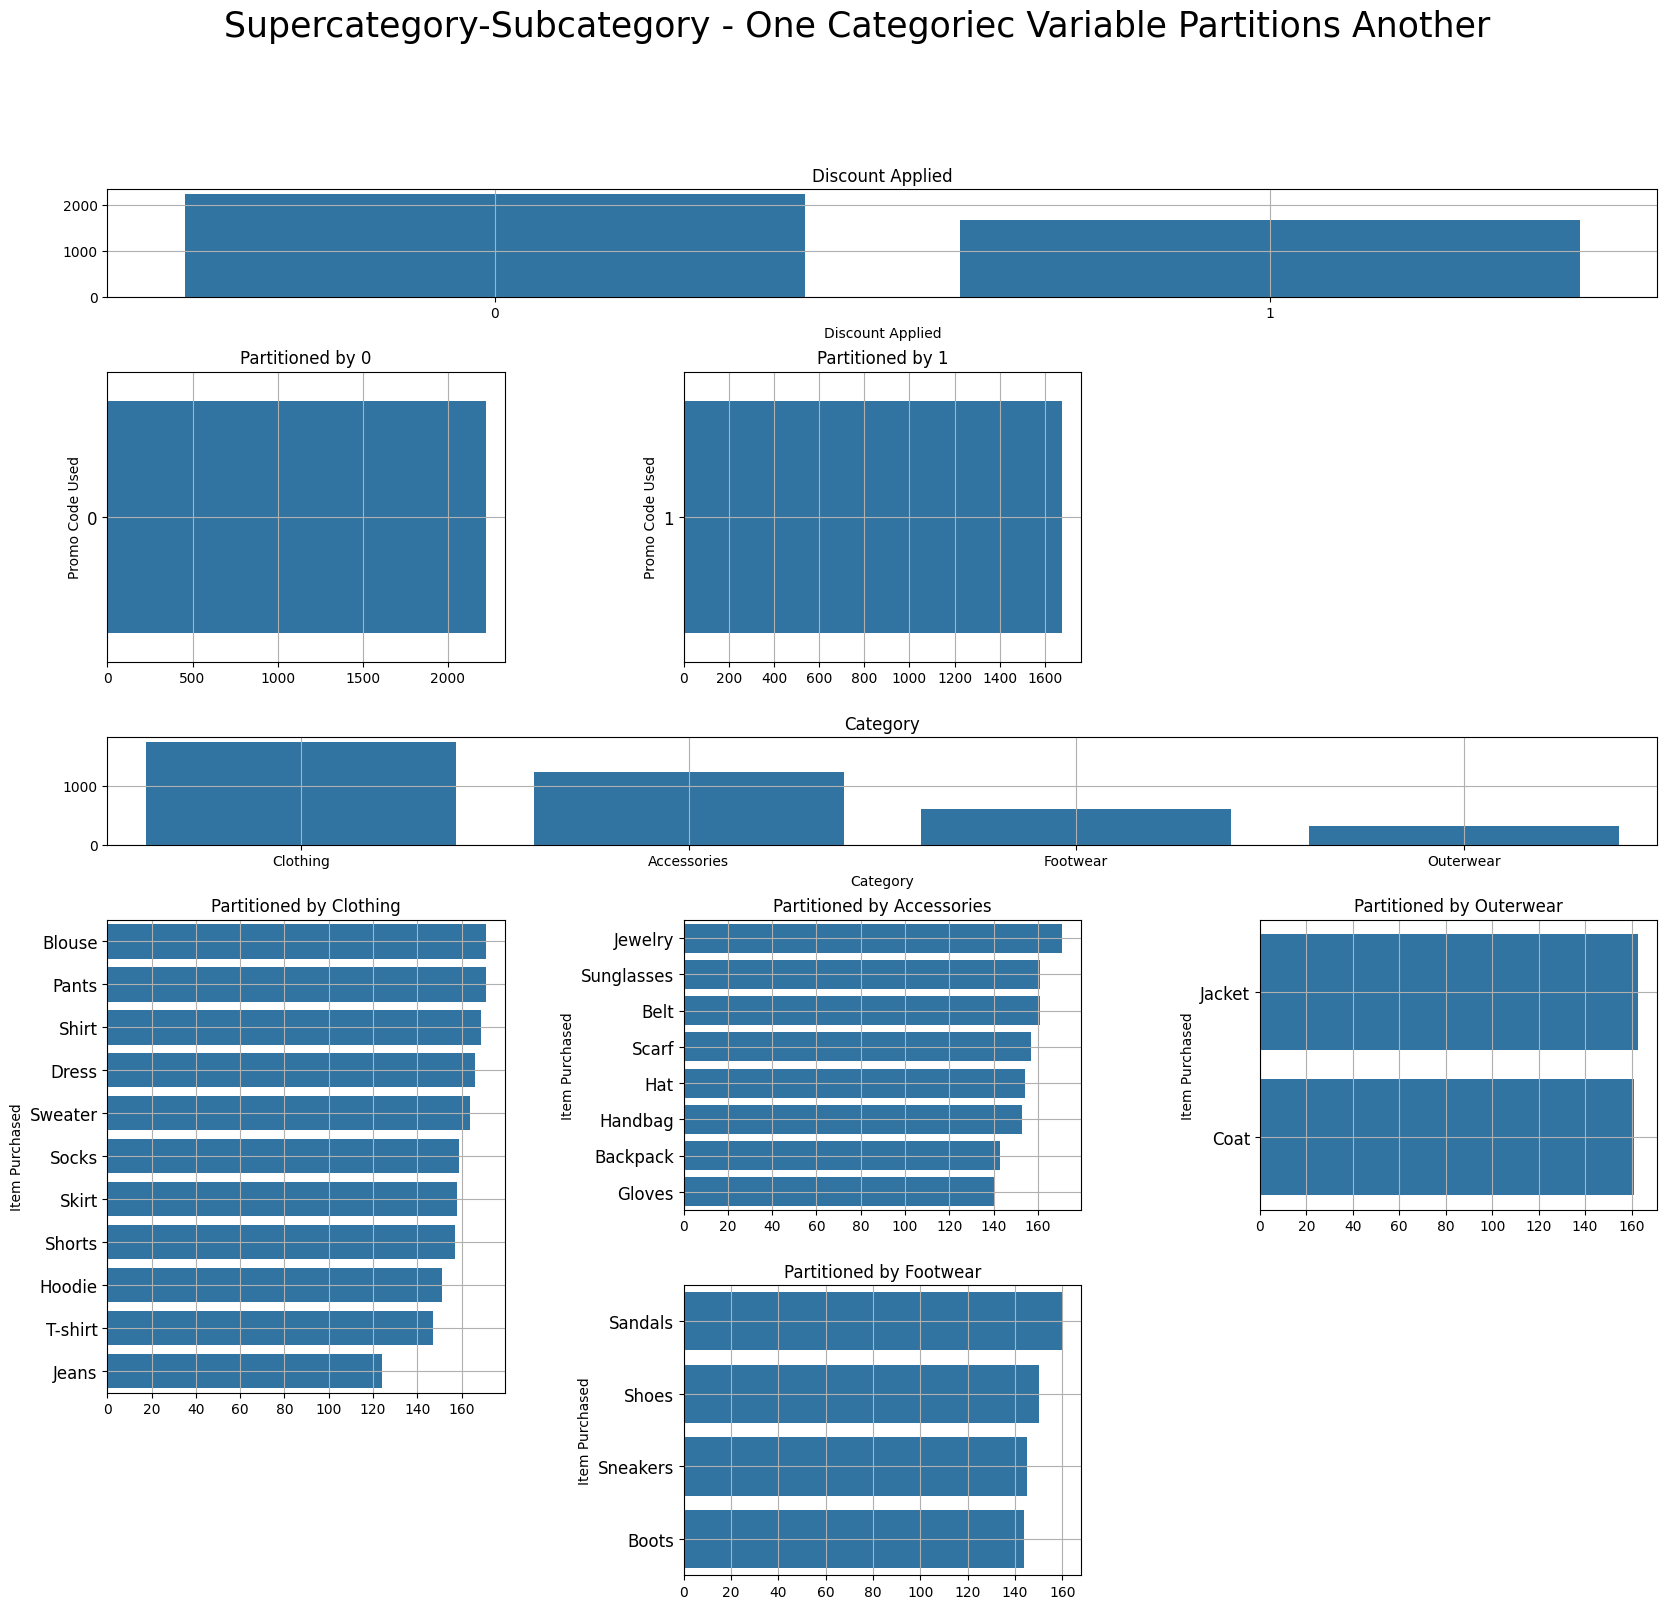

In [36]:
AD.produce_all_plots(df)